
# Layer Normalization на Triton

В ноутбуке реализованы:

1. forward pass для LayerNorm;
2. backward pass для `dx`, `dweight`, `dbias`;
3. проверка корректности через `torch.testing.assert_close`;
4. autotune Triton-кернелов;
5. benchmark против реализации на PyTorch.

Ожидаемый формат входа: матрица `x` размера `[M, N]`, где нормализация выполняется по последней оси `N`.


In [1]:
import math
import time
from typing import Iterable

import torch
import triton
import triton.language as tl
import matplotlib.pyplot as plt

print(f"torch: {torch.__version__}")
print(f"triton: {triton.__version__}")
print(f"cuda available: {torch.cuda.is_available()}")

if not torch.cuda.is_available():
    raise RuntimeError("Для этого ноутбука нужна CUDA GPU. В Colab включите Runtime -> Change runtime type -> GPU.")

DEVICE = "cuda"
torch.manual_seed(321)

torch: 2.10.0+cu128
triton: 3.6.0
cuda available: True



## Эталонная реализация на PyTorch


In [2]:
def layernorm_forward_torch(
    x: torch.Tensor,
    weight: torch.Tensor,
    bias: torch.Tensor,
    eps: float = 1e-5,
) -> torch.Tensor:
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, unbiased=False, keepdim=True)
    rstd = 1.0 / torch.sqrt(var + eps)
    x_hat = (x - mean) * rstd
    output = x_hat * weight + bias
    return output


## Triton kernels

Forward kernel считает одну строку `x[row, :]` в одном Triton program. Для backward используется формула:

$$
\hat{x} = (x - \mu) \cdot rstd
$$

$$
 dy_w = dy \cdot weight
$$

$$
 dx = rstd \cdot \left(dy_w - \operatorname{mean}(dy_w) - \hat{x} \cdot \operatorname{mean}(dy_w \cdot \hat{x})\right)
$$

Градиенты по параметрам:

$$
 d_{weight} = \sum_m dy_m \cdot \hat{x}_m, \quad dbias = \sum_m dy_m
$$

Для накопления `dweight` и `dbias` по оси `M` используется `tl.atomic_add`.


In [3]:
_AUTOTUNE_CONFIGS = [
    triton.Config({}, num_warps=1),
    triton.Config({}, num_warps=2),
    triton.Config({}, num_warps=4),
    triton.Config({}, num_warps=8),
]


@triton.autotune(configs=_AUTOTUNE_CONFIGS, key=["N"])
@triton.heuristics({"BLOCK_SIZE": lambda args: triton.next_power_of_2(args["N"])})
@triton.jit
def _layernorm_forward_kernel(
    x_ptr,
    weight_ptr,
    bias_ptr,
    y_ptr,
    mean_ptr,
    rstd_ptr,
    N: tl.constexpr,
    eps: tl.constexpr,
    BLOCK_SIZE: tl.constexpr,
):
    row = tl.program_id(0)
    offsets = tl.arange(0, BLOCK_SIZE)
    mask = offsets < N
    row_offsets = row * N + offsets

    x = tl.load(x_ptr + row_offsets, mask=mask, other=0.0).to(tl.float32)
    weight = tl.load(weight_ptr + offsets, mask=mask, other=0.0).to(tl.float32)
    bias = tl.load(bias_ptr + offsets, mask=mask, other=0.0).to(tl.float32)

    mean = tl.sum(x, axis=0) / N
    centered = tl.where(mask, x - mean, 0.0)
    var = tl.sum(centered * centered, axis=0) / N
    rstd = 1.0 / tl.sqrt(var + eps)
    x_hat = centered * rstd
    y = x_hat * weight + bias

    tl.store(y_ptr + row_offsets, y, mask=mask)
    tl.store(mean_ptr + row, mean)
    tl.store(rstd_ptr + row, rstd)


@triton.autotune(
    configs=_AUTOTUNE_CONFIGS,
    key=["N"],
    reset_to_zero=["dweight_ptr", "dbias_ptr"],
)
@triton.heuristics({"BLOCK_SIZE": lambda args: triton.next_power_of_2(args["N"])})
@triton.jit
def _layernorm_backward_kernel(
    dy_ptr,
    x_ptr,
    weight_ptr,
    mean_ptr,
    rstd_ptr,
    dx_ptr,
    dweight_ptr,
    dbias_ptr,
    N: tl.constexpr,
    BLOCK_SIZE: tl.constexpr,
):
    row = tl.program_id(0)
    offsets = tl.arange(0, BLOCK_SIZE)
    mask = offsets < N
    row_offsets = row * N + offsets

    dy = tl.load(dy_ptr + row_offsets, mask=mask, other=0.0).to(tl.float32)
    x = tl.load(x_ptr + row_offsets, mask=mask, other=0.0).to(tl.float32)
    weight = tl.load(weight_ptr + offsets, mask=mask, other=0.0).to(tl.float32)
    mean = tl.load(mean_ptr + row).to(tl.float32)
    rstd = tl.load(rstd_ptr + row).to(tl.float32)

    x_hat = (x - mean) * rstd
    dy_weight = dy * weight

    mean_dy_weight = tl.sum(dy_weight, axis=0) / N
    mean_dy_weight_xhat = tl.sum(dy_weight * x_hat, axis=0) / N

    dx = (dy_weight - mean_dy_weight - x_hat * mean_dy_weight_xhat) * rstd

    tl.store(dx_ptr + row_offsets, dx, mask=mask)
    tl.atomic_add(dweight_ptr + offsets, dy * x_hat, sem="relaxed", mask=mask)
    tl.atomic_add(dbias_ptr + offsets, dy, sem="relaxed", mask=mask)

**Важно про backward autotune.** В backward kernel используется `tl.atomic_add` для накопления `dweight` и `dbias`. Поэтому в `@triton.autotune` указан `reset_to_zero=["dweight_ptr", "dbias_ptr"]`: без этого autotune запускает kernel несколько раз на одних и тех же выходных буферах, и градиенты параметров накапливаются повторно.



## Python wrappers


In [4]:
def _check_inputs(x: torch.Tensor, weight: torch.Tensor, bias: torch.Tensor) -> tuple[int, int]:
    if x.ndim != 2:
        raise ValueError(f"x должен иметь форму [M, N], получено: {tuple(x.shape)}")
    if not x.is_cuda or not weight.is_cuda or not bias.is_cuda:
        raise ValueError("x, weight и bias должны находиться на CUDA")
    if weight.ndim != 1 or bias.ndim != 1:
        raise ValueError("weight и bias должны быть одномерными тензорами")
    if x.shape[-1] != weight.numel() or x.shape[-1] != bias.numel():
        raise ValueError("Размеры последней оси x, weight и bias не совпадают")

    M, N = x.shape
    block_size = triton.next_power_of_2(N)
    if block_size > 131072:
        raise ValueError("Слишком большой hidden size для одного Triton block")

    return M, N


def layernorm_forward_triton(
    x: torch.Tensor,
    weight: torch.Tensor,
    bias: torch.Tensor,
    eps: float = 1e-5,
    return_stats: bool = False,
):
    x = x.contiguous()
    weight = weight.contiguous()
    bias = bias.contiguous()

    M, N = _check_inputs(x, weight, bias)

    y = torch.empty_like(x)
    mean = torch.empty((M,), device=x.device, dtype=torch.float32)
    rstd = torch.empty((M,), device=x.device, dtype=torch.float32)

    _layernorm_forward_kernel[(M,)](
        x,
        weight,
        bias,
        y,
        mean,
        rstd,
        N=N,
        eps=eps,
    )

    if return_stats:
        return y, mean, rstd
    return y


def layernorm_backward_triton(
    dy: torch.Tensor,
    x: torch.Tensor,
    weight: torch.Tensor,
    mean: torch.Tensor,
    rstd: torch.Tensor,
):
    dy = dy.contiguous()
    x = x.contiguous()
    weight = weight.contiguous()

    if dy.shape != x.shape:
        raise ValueError("dy и x должны иметь одинаковую форму")

    M, N = x.shape
    dx = torch.empty_like(x)
    dweight = torch.zeros_like(weight)
    dbias = torch.zeros_like(weight)

    _layernorm_backward_kernel[(M,)](
        dy,
        x,
        weight,
        mean,
        rstd,
        dx,
        dweight,
        dbias,
        N=N,
    )

    return dx, dweight, dbias


class TritonLayerNormFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x: torch.Tensor, weight: torch.Tensor, bias: torch.Tensor, eps: float = 1e-5):
        y, mean, rstd = layernorm_forward_triton(x, weight, bias, eps=eps, return_stats=True)
        ctx.save_for_backward(x, weight, mean, rstd)
        return y

    @staticmethod
    def backward(ctx, dy: torch.Tensor):
        x, weight, mean, rstd = ctx.saved_tensors
        dx, dweight, dbias = layernorm_backward_triton(dy, x, weight, mean, rstd)
        return dx, dweight, dbias, None


def layernorm_triton(x: torch.Tensor, weight: torch.Tensor, bias: torch.Tensor, eps: float = 1e-5):
    return TritonLayerNormFunction.apply(x, weight, bias, eps)


## Проверка корректности forward pass


In [5]:
def make_inputs(M: int, N: int, dtype: torch.dtype = torch.float32):
    x = torch.randn((M, N), device=DEVICE, dtype=dtype)
    weight = torch.randn((N,), device=DEVICE, dtype=dtype)
    bias = torch.randn((N,), device=DEVICE, dtype=dtype)
    return x, weight, bias


def check_forward(shapes: Iterable[tuple[int, int]], eps: float = 1e-5):
    for M, N in shapes:
        x, weight, bias = make_inputs(M, N, dtype=torch.float32)
        y_torch = layernorm_forward_torch(x, weight, bias, eps=eps)
        y_triton = layernorm_forward_triton(x, weight, bias, eps=eps)

        torch.testing.assert_close(y_triton, y_torch, rtol=1e-4, atol=1e-4)
        print(f"forward ok: M={M}, N={N}")


FORWARD_TEST_SHAPES = [
    (8, 128),
    (32, 513),
    (128, 768),
    (256, 1024),
    (64, 4096),
]

check_forward(FORWARD_TEST_SHAPES)

forward ok: M=8, N=128
forward ok: M=32, N=513
forward ok: M=128, N=768
forward ok: M=256, N=1024
forward ok: M=64, N=4096



## Проверка корректности backward pass


In [6]:
def check_backward(shapes: Iterable[tuple[int, int]], eps: float = 1e-5):
    for M, N in shapes:
        x = torch.randn((M, N), device=DEVICE, dtype=torch.float32, requires_grad=True)
        weight = torch.randn((N,), device=DEVICE, dtype=torch.float32, requires_grad=True)
        bias = torch.randn((N,), device=DEVICE, dtype=torch.float32, requires_grad=True)
        dy = torch.randn((M, N), device=DEVICE, dtype=torch.float32)

        x_ref = x.detach().clone().requires_grad_(True)
        weight_ref = weight.detach().clone().requires_grad_(True)
        bias_ref = bias.detach().clone().requires_grad_(True)

        y_ref = layernorm_forward_torch(x_ref, weight_ref, bias_ref, eps=eps)
        y_ref.backward(dy)

        y_tri = layernorm_triton(x, weight, bias, eps=eps)
        y_tri.backward(dy)

        torch.testing.assert_close(y_tri.detach(), y_ref.detach(), rtol=1e-4, atol=1e-4)
        torch.testing.assert_close(x.grad, x_ref.grad, rtol=1e-4, atol=1e-4)
        torch.testing.assert_close(weight.grad, weight_ref.grad, rtol=2e-4, atol=2e-4)
        torch.testing.assert_close(bias.grad, bias_ref.grad, rtol=2e-4, atol=2e-4)

        print(f"backward ok: M={M}, N={N}")


BACKWARD_TEST_SHAPES = [
    (8, 128),
    (32, 513),
    (128, 768),
    (256, 1024),
    (64, 4096),
]

check_backward(BACKWARD_TEST_SHAPES)

backward ok: M=8, N=128
backward ok: M=32, N=513
backward ok: M=128, N=768
backward ok: M=256, N=1024
backward ok: M=64, N=4096



## Benchmark

Ниже сравнивается скорость PyTorch и Triton. Для измерения используется `triton.testing.do_bench`, который корректно синхронизирует CUDA-операции.


In [7]:
def approx_forward_gb(M: int, N: int, dtype: torch.dtype) -> float:
    element_size = torch.empty((), dtype=dtype).element_size()
    bytes_count = M * N * element_size * 2 + 2 * N * element_size + 2 * M * 4
    return bytes_count / 1e9


def approx_fwd_bwd_gb(M: int, N: int, dtype: torch.dtype) -> float:
    element_size = torch.empty((), dtype=dtype).element_size()
    bytes_count = M * N * element_size * 8 + 4 * N * element_size + 2 * M * 4
    return bytes_count / 1e9


def bench_forward(M: int, N: int, dtype: torch.dtype = torch.float32, eps: float = 1e-5):
    x, weight, bias = make_inputs(M, N, dtype=dtype)

    torch_ms = triton.testing.do_bench(
        lambda: layernorm_forward_torch(x, weight, bias, eps=eps),
        warmup=25,
        rep=100,
    )
    triton_ms = triton.testing.do_bench(
        lambda: layernorm_forward_triton(x, weight, bias, eps=eps),
        warmup=25,
        rep=100,
    )

    gb = approx_forward_gb(M, N, dtype)
    return {
        "M": M,
        "N": N,
        "mode": "forward",
        "torch_ms": torch_ms,
        "triton_ms": triton_ms,
        "speedup": torch_ms / triton_ms,
        "torch_GBps": gb / (torch_ms * 1e-3),
        "triton_GBps": gb / (triton_ms * 1e-3),
    }


def bench_forward_backward(M: int, N: int, dtype: torch.dtype = torch.float32, eps: float = 1e-5):
    x = torch.randn((M, N), device=DEVICE, dtype=dtype, requires_grad=True)
    weight = torch.randn((N,), device=DEVICE, dtype=dtype, requires_grad=True)
    bias = torch.randn((N,), device=DEVICE, dtype=dtype, requires_grad=True)
    dy = torch.randn((M, N), device=DEVICE, dtype=dtype)

    def torch_step():
        x.grad = None
        weight.grad = None
        bias.grad = None
        y = layernorm_forward_torch(x, weight, bias, eps=eps)
        y.backward(dy)

    def triton_step():
        x.grad = None
        weight.grad = None
        bias.grad = None
        y = layernorm_triton(x, weight, bias, eps=eps)
        y.backward(dy)

    torch_ms = triton.testing.do_bench(torch_step, warmup=25, rep=100)
    triton_ms = triton.testing.do_bench(triton_step, warmup=25, rep=100)

    gb = approx_fwd_bwd_gb(M, N, dtype)
    return {
        "M": M,
        "N": N,
        "mode": "forward+backward",
        "torch_ms": torch_ms,
        "triton_ms": triton_ms,
        "speedup": torch_ms / triton_ms,
        "torch_GBps": gb / (torch_ms * 1e-3),
        "triton_GBps": gb / (triton_ms * 1e-3),
    }


def print_report(rows):
    header = f"{'mode':<18} {'M':>6} {'N':>6} {'torch, ms':>12} {'triton, ms':>12} {'speedup':>10} {'torch GB/s':>12} {'triton GB/s':>13}"
    print(header)
    print('-' * len(header))
    for row in rows:
        print(
            f"{row['mode']:<18} "
            f"{row['M']:>6} "
            f"{row['N']:>6} "
            f"{row['torch_ms']:>12.4f} "
            f"{row['triton_ms']:>12.4f} "
            f"{row['speedup']:>10.3f} "
            f"{row['torch_GBps']:>12.2f} "
            f"{row['triton_GBps']:>13.2f}"
        )

In [8]:
BENCH_SHAPES = [
    (1024, 768),
    (2048, 1024),
    (2048, 2048),
]

benchmark_rows = []
for M, N in BENCH_SHAPES:
    benchmark_rows.append(bench_forward(M, N))
    benchmark_rows.append(bench_forward_backward(M, N))

print_report(benchmark_rows)

mode                    M      N    torch, ms   triton, ms    speedup   torch GB/s   triton GB/s
------------------------------------------------------------------------------------------------
forward              1024    768       0.1505       0.0302      4.985        41.90        208.87
forward+backward     1024    768       1.8516       0.1464     12.646        13.60        172.02
forward              2048   1024       0.3860       0.0793      4.869        43.53        211.94
forward+backward     2048   1024       1.4430       0.2659      5.426        46.53        252.47
forward              2048   2048       0.7333       0.1619      4.531        45.80        207.51
forward+backward     2048   2048       2.7426       0.3759      7.296        48.96        357.18


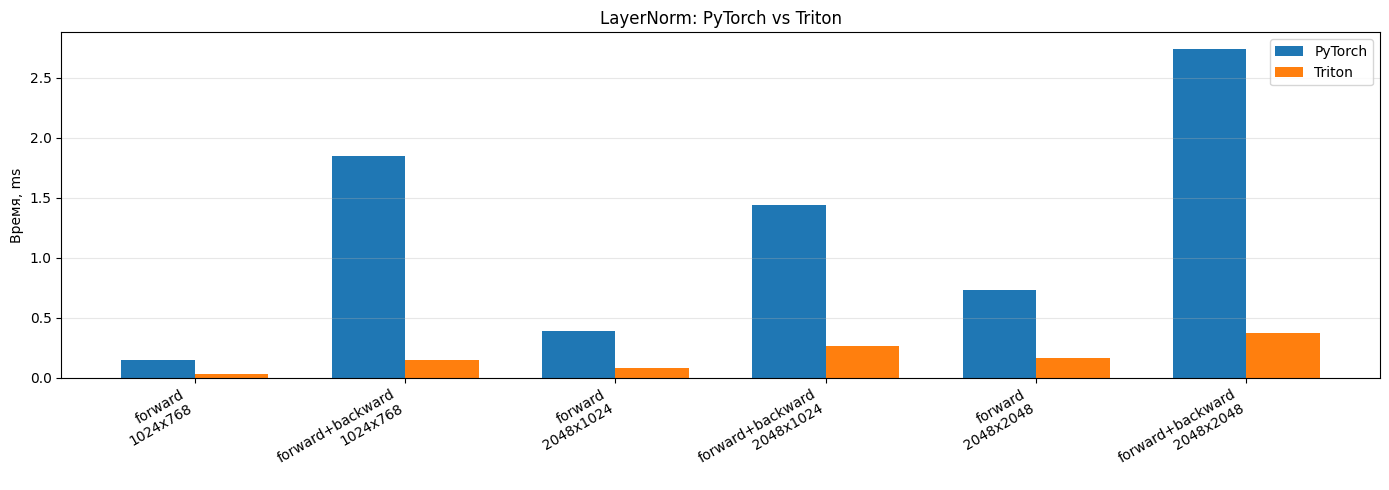

In [9]:
labels = [f"{row['mode']}\n{row['M']}x{row['N']}" for row in benchmark_rows]
torch_values = [row["torch_ms"] for row in benchmark_rows]
triton_values = [row["triton_ms"] for row in benchmark_rows]

x_pos = range(len(labels))
width = 0.35

plt.figure(figsize=(14, 5))
plt.bar([x - width / 2 for x in x_pos], torch_values, width=width, label="PyTorch")
plt.bar([x + width / 2 for x in x_pos], triton_values, width=width, label="Triton")
plt.xticks(list(x_pos), labels, rotation=30, ha="right")
plt.ylabel("Время, ms")
plt.title("LayerNorm: PyTorch vs Triton")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()